<a href="https://colab.research.google.com/github/adljna/Blu-SentimentAnalysis/blob/main/Week%202-3/2-Preprocessing-BluAppReview.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Week 2 - Preprocessing Blu App Review**
This notebook continues the review scraping process previously explained in [1-Scrapping-BluAppReview.ipynb](https://colab.research.google.com/drive/1XOnxtGNkffOdXslITOG4ay1UeZ5lXTui?usp=sharing)

# **Preprocessing Pipeline**

> In this stage, a series of text preprocessing steps are applied to clean and standardize the review data before further analysis. This process aims to reduce noise, improve text quality, and enhance the performance of subsequent sentiment analysis.



The preprocessing pipeline consists of the following steps:
1. Lowercasing: Converting all text into lowercase to ensure consistency.
3. Punctuation Removal: Removing punctuation marks that do not contribute to meaning.
4. Stopword Removal: Eliminating commonly used words (e.g., "and", "the") that carry little semantic value.
2. Tokenization: Splitting text into individual words or tokens.
5. Stemming/Lemmatization: Reducing words to their root or base form.
6. Expand Contractions: Converting shortened words (e.g., "don't" → "do not") into their full forms.
7. Spelling Correction: Correcting misspelled words to improve text accuracy.
8. Rare Words Removal: Removing infrequent words that may introduce noise.
9. Common Words Removal: Filtering overly frequent words that do not add meaningful information.




#**Setup and Import Libraries**



In [ ]:
!pip install Sastrawi -q
!pip install emoji -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 9.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import regex
import re
import string
import emoji
from collections import Counter
from textblob import TextBlob

import nltk
from nltk import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

import wordcloud
from wordcloud import WordCloud, STOPWORDS

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

#**Load Dataset**

In [ ]:
from google.colab import files
uploaded = files.upload()

import io
import pandas as pd

for fn in uploaded.keys():
    print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

    try:
        df_bluRev = pd.read_csv(io.BytesIO(uploaded[fn]))
        print("Successfully loaded CSV into df_bluRev")

    except pd.errors.ParserError:
        print(f"Error: Could not parse {fn} as a CSV. Please upload a valid CSV file.")
        df_bluRev = pd.DataFrame()

    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        df_bluRev = pd.DataFrame()

Saving df_bluRev.csv to df_bluRev (2).csv
User uploaded file "df_bluRev (2).csv" with length 15051381 bytes
Successfully loaded CSV into df_bluRev


In [ ]:
df_bluRev

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,30dfaf9a-79bd-4781-b4aa-0f74ab74cc57,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"udah lebih dr 1 mnggu, gk bisa di buka udah ga...",2,0,2.10.10,2026-03-30 09:10:30,"Hai, Kak Indah. Maaf atas ketidaknyamanannya. ...",2026-03-30 09:33:32,2.10.10
1,2da4b203-3b45-46b9-afa5-889151fd6252,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"bener bener kecewa sama aplikasi ini, gw kira ...",1,0,NaN,2026-03-30 08:05:12,"Hai, Kak Esa. Maaf atas ketidaknyamanannya. BC...",2026-03-30 08:49:54,NaN
2,87d30962-44f0-49f3-b9cf-c006cc673101,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mantap,5,0,2.10.10,2026-03-30 08:01:13,"Hai, Kak Abdul. Terima kasih atas ulasannya. S...",2026-03-30 08:06:43,2.10.10
3,1dbe588f-f90e-45d8-bccf-b147c9ca2c8c,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,digital bank terbaik gaperlu ribet lagi pembay...,5,0,2.10.10,2026-03-30 07:38:52,"Hai, Kak Kenzin. Terima kasih atas ulasannya. ...",2026-03-30 08:06:06,2.10.10
4,ba22093f-ce6c-4e5c-ab6a-a427affb0b08,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"aku tinggalkan blu, karena aplikasinya super l...",5,0,2.3.0,2026-03-30 07:00:00,"Hai, Kak Rizal. Maaf atas ketidaknyamanannya. ...",2026-03-30 08:02:48,2.3.0
...,...,...,...,...,...,...,...,...,...,...,...
25782,378e0b3f-7144-46b8-bd4e-8bb80870f6e2,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Selamat pagi masyarakat BCA DIGITAL, hehehehe😁...",5,0,1.3.2,2021-07-02 02:59:18,"Hai, Kak Ridwan Mukti Sastama. Terima kasih at...",2021-07-04 08:24:53,1.3.2
25783,4086e9bd-571f-4d99-815b-485e7d6bc2e3,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Ribet ...minta diaktifkan screen lock, dah akt...",1,0,1.3.2,2021-07-02 02:53:23,"Hai, Kak Hidayat Hidayat. Terima kasih untuk f...",2021-07-04 07:59:53,1.3.2
25784,969313e4-7943-430e-8cf8-ceb734b954df,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Video call kok ngk berhasil,5,0,1.3.2,2021-07-02 02:50:42,"Hai, Kak Roni Susanto. Terima kasih untuk feed...",2021-07-04 07:49:57,1.3.2
25785,5437120e-6d6c-4201-96a1-7fc5344c5ff4,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Pertamax....test,3,1,NaN,2021-07-02 02:42:19,"Hai, Kak Zainal CorRosion. Terima kasih atas u...",2021-07-04 07:34:47,NaN


In [ ]:
# Display dataset structure and check data types and missing values
df_bluRev.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25787 entries, 0 to 25786
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              25787 non-null  object
 1   userName              25787 non-null  object
 2   userImage             25787 non-null  object
 3   content               25787 non-null  object
 4   score                 25787 non-null  int64 
 5   thumbsUpCount         25787 non-null  int64 
 6   reviewCreatedVersion  21544 non-null  object
 7   at                    25787 non-null  object
 8   replyContent          25787 non-null  object
 9   repliedAt             25787 non-null  object
 10  appVersion            21544 non-null  object
dtypes: int64(2), object(9)
memory usage: 2.2+ MB


#**Drop Unnecessary Column Selection**

In [ ]:
# Drop reviewId, userName, userImage
df_bluRev = df_bluRev.loc[:,["content","score","thumbsUpCount", "reviewCreatedVersion", "at", "replyContent", "repliedAt"]]

#**Case Folding**

In [ ]:
# Make sure the content column is of type string
df_bluRev['content'] = df_bluRev['content'].astype(str)

# Change all text to lowercase
df_bluRev['cleaned_content'] = df_bluRev['content'].str.lower()

# Example after lowercasing
print("\nAfter lowercasing:")
print(df_bluRev['cleaned_content'][1])


After lowercasing:
bener bener kecewa sama aplikasi ini, gw kira terpercaya ternyata sama sekali nggak recomended karna ngga ada kantor cabang fisik yg jelas dan pelaporan cuma by apk halo bca doang wkwkwk, mana prosesnya lama dan nggak jelas lagii


# **Punctuation & Special Characters Removal**

In [ ]:
def clean_text(text):
    text = str(text)

    # Remove emoji
    text = re.sub(r'[\U00010000-\U0010ffff]', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove special characters (keep letters)
    text = re.sub(r'[^a-z\s]', '', text)
    return text

df_bluRev['cleaned_content'] = df_bluRev['cleaned_content'].apply(clean_text)

# Example
print(df_bluRev['cleaned_content'].iloc[1])

bener bener kecewa sama aplikasi ini gw kira terpercaya ternyata sama sekali nggak recomended karna ngga ada kantor cabang fisik yg jelas dan pelaporan cuma by apk halo bca doang wkwkwk mana prosesnya lama dan nggak jelas lagii


#**Text Normalization - Spelling Correction**

In [ ]:
# Indonesian slang dictionary based on app reviews
idslang_dict = {
    'gak': 'tidak', 'ga': 'tidak', 'gk': 'tidak', 'g': 'tidak',
    'tdk': 'tidak', 'nggak': 'tidak', 'ngga': 'tidak', 'kagak': 'tidak',
    'engga': 'tidak', 'enggak': 'tidak', 'ngk': 'tidak',
    'tp': 'tapi', 'tpi': 'tapi',
    'krn': 'karena', 'karna': 'karena', 'krna': 'karena',
    'sy': 'saya', 'aku': 'saya', 'gw': 'saya', 'gue': 'saya', 'gua': 'saya', 'w': 'saya',
    'lo': 'kamu', 'lu': 'kamu',
    'yg': 'yang', 'yng': 'yang',
    'dg': 'dengan', 'dgn': 'dengan', 'sm': 'dengan',
    'dr': 'dari',
    'utk': 'untuk', 'tuk': 'untuk', 'u': 'untuk',
    'udh': 'sudah', 'sdh': 'sudah', 'udah': 'sudah', 'uda': 'sudah',
    'blm': 'belum', 'blom': 'belum',
    'lg': 'lagi', 'lgi': 'lagi',
    'skrg': 'sekarang', 'skrng': 'sekarang', 'skg': 'sekarang',
    'trs': 'terus', 'trus': 'terus',
    'bs': 'bisa', 'bsa': 'bisa',
    'hrs': 'harus',
    'jd': 'jadi', 'jdi': 'jadi',
    'dpt': 'dapat',
    'pke': 'pakai', 'pake': 'pakai', 'pk': 'pakai', 'makek' : 'pakai',
    'gmn': 'bagaimana', 'gimana': 'bagaimana',
    'knp': 'kenapa', 'knapa': 'kenapa',
    'dmn': 'dimana', 'dmna': 'dimana',
    'bgt': 'banget', 'bngt': 'banget', 'bngtt': 'banget',
    'bgtt': 'banget', 'bangett': 'banget',
    'mantap': 'bagus', 'mantab': 'bagus', 'mantapp': 'bagus',
    'keren': 'bagus', 'top': 'bagus',
    'jelek': 'buruk', 'parah': 'buruk', 'ancur': 'buruk', 'sampah': 'buruk',
    'apk': 'aplikasi', 'app': 'aplikasi',
    'eror': 'error', 'erorr': 'error', 'errorr': 'error',
    'lemot': 'lambat', 'lelet': 'lambat',
    'lag': 'lambat', 'ngelag': 'lambat',
    'crash': 'error', 'force close': 'error',
    'login': 'masuk', 'log in': 'masuk',
    'logout': 'keluar',
    'update': 'perbarui', 'upd': 'perbarui',
    'verif': 'verifikasi', 'verifikasiin': 'verifikasi',
    'makasih': 'terima kasih', 'makasi': 'terima kasih',
    'thx': 'terima kasih', 'thanks': 'terima kasih', 'tq': 'terima kasih',
    'org': 'orang', 'ornag': 'orang',
    'msh': 'masih',
    'bkn': 'bukan',
    'gpp': 'tidak apa apa', 'gapapa': 'tidak apa apa',
    'dlu': 'dulu', 'dl': 'dulu',
    'ntar': 'nanti', 'tar': 'nanti',
    'kmrn': 'kemarin', 'kmarin': 'kemarin',
    'mnggu': 'minggu', 'dlm' : 'dalam', 'bener' : 'benar',
}

print(f"Slang dictionary size: {len(idslang_dict)} entries")

Slang dictionary size: 113 entries


In [ ]:
def normalize_slang(text):
    words = text.split()
    normalized = [idslang_dict.get(word, word) for word in words]
    return ' '.join(normalized)

df_bluRev['cleaned_content'] = df_bluRev['cleaned_content'].apply(normalize_slang)

changed_mask = (
    df_bluRev['content'].astype(str) != df_bluRev['cleaned_content']
)

df_bluRev.loc[changed_mask, ['content', 'cleaned_content']].head(10)

,content,cleaned_content
0,"udah lebih dr 1 mnggu, gk bisa di buka udah ga...",sudah lebih dari minggu tidak bisa di buka sud...
1,"bener bener kecewa sama aplikasi ini, gw kira ...",benar benar kecewa sama aplikasi ini saya kira...
2,mantap,bagus
4,"aku tinggalkan blu, karena aplikasinya super l...",saya tinggalkan blu karena aplikasinya super l...
5,alhamdulillah sangat bagus aplikasi nya terima...,alhamdulillah sangat bagus aplikasi nya terima...
7,"Bagus banget, userfriendly, stabil, aman",bagus banget userfriendly stabil aman
11,sangat membantu saya dlm melakukan transaksi k...,sangat membantu saya dalam melakukan transaksi...
13,paling enak bertransaksi pake blu .. jdi gak p...,paling enak bertransaksi pakai blu jadi tidak ...
14,"nice, amazing",nice amazing
15,kenapa kartu blu nya tidak bisa di gunakan di ...,kenapa kartu blu nya tidak bisa di gunakan di ...


# **Tokenization**


In [ ]:
df_bluRev['tokens'] = df_bluRev['cleaned_content'].apply(word_tokenize)
df_bluRev['token_count'] = df_bluRev['tokens'].apply(len)
df_bluRev[['cleaned_content', 'tokens', 'token_count']].head(5)

,cleaned_content,tokens,token_count
0,sudah lebih dari minggu tidak bisa di buka sud...,"[sudah, lebih, dari, minggu, tidak, bisa, di, ...",21
1,benar benar kecewa sama aplikasi ini saya kira...,"[benar, benar, kecewa, sama, aplikasi, ini, sa...",38
2,bagus,[bagus],1
3,digital bank terbaik gaperlu ribet lagi pembay...,"[digital, bank, terbaik, gaperlu, ribet, lagi,...",9
4,saya tinggalkan blu karena aplikasinya super l...,"[saya, tinggalkan, blu, karena, aplikasinya, s...",7


In [ ]:
total_tokens = df_bluRev['tokens'].apply(len).sum()
print(f"Total tokens in dataset: {total_tokens}")

Total tokens in dataset: 314192


# **Stopwords Removal**

In [ ]:
try:
    stopwords.words('indonesian')
except LookupError:
    nltk.download('stopwords')

stop_words = set(
    stopwords.words('indonesian') +
    ["nya", "aja", "ya", "aplikasi", "bank", "blu", "bca", "digital"]
)

print(f"Total stopwords: {len(stop_words)}")
print("Sample stopwords:", list(stop_words)[:20])

Total stopwords: 765
Sample stopwords: ['berada', 'rasa', 'lainnya', 'bahkan', 'adalah', 'sedikit', 'diibaratkan', 'sebutlah', 'wah', 'sedikitnya', 'pertanyaan', 'bawah', 'berkata', 'mereka', 'namun', 'khususnya', 'ingat', 'selain', 'justru', 'keluar']


In [ ]:
df_bluRev['filtered_tokens'] = df_bluRev['tokens'].apply(
    lambda tokens: [word for word in tokens if word not in stop_words]
)
df_bluRev['final_token_count'] = df_bluRev['filtered_tokens'].apply(len)
df_bluRev[['tokens', 'filtered_tokens', 'final_token_count']].head(10)

,tokens,filtered_tokens,final_token_count
0,"[sudah, lebih, dari, minggu, tidak, bisa, di, ...","[minggu, buka, ganti, jaringan, dn, ganti, hp,...",11
1,"[benar, benar, kecewa, sama, aplikasi, ini, sa...","[kecewa, terpercaya, recomended, kantor, caban...",13
2,[bagus],[bagus],1
3,"[digital, bank, terbaik, gaperlu, ribet, lagi,...","[terbaik, gaperlu, ribet, pembayaran, jenis, a...",6
4,"[saya, tinggalkan, blu, karena, aplikasinya, s...","[tinggalkan, aplikasinya, super, lambat]",4
5,"[alhamdulillah, sangat, bagus, aplikasi, nya, ...","[alhamdulillah, bagus, terimakasih]",3
6,[mantappp],[mantappp],1
7,"[bagus, banget, userfriendly, stabil, aman]","[bagus, banget, userfriendly, stabil, aman]",5
8,[good],[good],1
9,"[enak, egk, ada, administrasi, bulanan]","[enak, egk, administrasi, bulanan]",4


# **Stemming**

In [ ]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stem_tokens(tokens):
    return [stemmer.stem(token) for token in tokens]

df_bluRev['tokens_stemmed'] = df_bluRev['filtered_tokens'].apply(stem_tokens)
df_bluRev[['filtered_tokens', 'tokens_stemmed']].head(10)

,filtered_tokens,tokens_stemmed
0,"[minggu, buka, ganti, jaringan, dn, ganti, hp,...","[minggu, buka, ganti, jaring, dn, ganti, hp, s..."
1,"[kecewa, terpercaya, recomended, kantor, caban...","[kecewa, percaya, recomended, kantor, cabang, ..."
2,[bagus],[bagus]
3,"[terbaik, gaperlu, ribet, pembayaran, jenis, a...","[baik, gaperlu, ribet, bayar, jenis, apa]"
4,"[tinggalkan, aplikasinya, super, lambat]","[tinggal, aplikasi, super, lambat]"
5,"[alhamdulillah, bagus, terimakasih]","[alhamdulillah, bagus, terimakasih]"
6,[mantappp],[mantappp]
7,"[bagus, banget, userfriendly, stabil, aman]","[bagus, banget, userfriendly, stabil, aman]"
8,[good],[good]
9,"[enak, egk, administrasi, bulanan]","[enak, egk, administrasi, bulan]"


#**Rare Words Removal**

In [ ]:
all_tokens = [t for tokens in df_bluRev['tokens_stemmed'] for t in tokens]
tokens_freq = Counter(all_tokens)

threshold = 2
rare_words = {w for w, f in tokens_freq.items() if f <= threshold}

print(f"Unique words       : {len(tokens_freq):,}")
print(f"Rare words (<= {threshold}) : {len(rare_words):,} "
      f"({len(rare_words)/len(tokens_freq)*100:.1f}% of vocab)")
print(f"Sample rare words  : {list(rare_words)[:15]}")

Unique words       : 15,076
Rare words (<= 2) : 11,589 (76.9% of vocab)
Sample rare words  : ['tasdompet', 'trz', 'sudsh', 'seringlemot', 'jerat', 'disiniklau', 'resoon', 'otamatis', 'joooos', 'econorm', 'mony', 'danaovo', 'adapake', 'uiuix', 'waltu']


In [ ]:
df_bluRev['tokens_filtered'] = df_bluRev['tokens_stemmed'].apply(
    lambda tokens: [w for w in tokens if w not in rare_words]
)

before = df_bluRev['tokens_stemmed'].apply(len).sum()
after  = df_bluRev['tokens_filtered'].apply(len).sum()

print(f"\nTokens removed: {before - after:,}")


Tokens removed: 13,160


#**Recombine into sentences**

In [ ]:
df_bluRev['final_content'] = df_bluRev['tokens_filtered'].apply(lambda x: ' '.join(x))
df_bluRev[['content', 'final_content']].head(10)

,content,final_content
0,"udah lebih dr 1 mnggu, gk bisa di buka udah ga...",minggu buka ganti jaring dn ganti hp sih data ...
1,"bener bener kecewa sama aplikasi ini, gw kira ...",kecewa percaya recomended kantor cabang fisik ...
2,mantap,bagus
3,digital bank terbaik gaperlu ribet lagi pembay...,baik gaperlu ribet bayar jenis apa
4,"aku tinggalkan blu, karena aplikasinya super l...",tinggal aplikasi super lambat
5,alhamdulillah sangat bagus aplikasi nya terima...,alhamdulillah bagus terimakasih
6,mantappp,mantappp
7,"Bagus banget, userfriendly, stabil, aman",bagus banget userfriendly stabil aman
8,good,good
9,enak egk ada administrasi bulanan,enak administrasi bulan


#**Processed Data Validation**

In [ ]:
# Compare before vs after
print("Before vs After")
display(df_bluRev[['content', 'final_content']].sample(5))

Before vs After


,content,final_content
23794,Seminggu lebih buat vc kagak kebagian antrian,minggu vc bagi antri
3059,cara foto ktpnya gimana potongannya ga sesuai ...,foto ktpnya potong sesuai
16979,Sanagat membantu bertransaksi,bantu transaksi
408,lobang Nye sangatlah rapat sakali milik BcA in...,rapat milik pon hari ontok ontok kartu salalu ...
133,siiip,siiip


In [ ]:
empty_text = (df_bluRev['final_content'].str.strip() == '').sum()
print(f"\nEmpty text after preprocessing: {empty_text}")



Empty text after preprocessing: 819


In [ ]:
df_bluRev = df_bluRev[df_bluRev['final_content'].str.strip() != '']
empty_text = (df_bluRev['final_content'].str.strip() == '').sum()
print(f"Empty text after removal: {empty_text}")

Empty text after removal: 0


In [ ]:
# Token length statistics
df_bluRev['final_token_count'] = df_bluRev['tokens_stemmed'].apply(len)

print("\n=== Token Statistics ===")
print(f"Average tokens: {df_bluRev['final_token_count'].mean():.2f}")
print(f"Max tokens: {df_bluRev['final_token_count'].max()}")
print(f"Min tokens: {df_bluRev['final_token_count'].min()}")


=== Token Statistics ===
Average tokens: 6.79
Max tokens: 66
Min tokens: 1


/tmp/ipykernel_33708/2948044685.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bluRev['final_token_count'] = df_bluRev['tokens_stemmed'].apply(len)


In [ ]:
# Check sample of very short texts
print("\n=== Very Short Texts (<=2 tokens) ===")
display(df_bluRev[df_bluRev['final_token_count'] <= 2][['final_content']].head(5))


=== Very Short Texts (<=2 tokens) ===


,final_content
2,bagus
6,mantappp
8,good
10,mudah
14,nice amazing


In [ ]:
# Check sample of very long texts
print("\n=== Very Long Texts (Top 5) ===")
display(df_bluRev.sort_values(by='final_token_count', ascending=False)[['final_content']].head(5))


=== Very Long Texts (Top 5) ===


,final_content
22676,tdinya mls antri atm bri cba pakai eh kaga acc...
2218,sore maaf sj pinjeman niat pinjam rek sesuai t...
12542,bayar pakai qr tgl april proses gagal saldo ku...
15146,hallo ka aj tdi download d sruh mba cs ny down...
12386,alamat wajib sesuai ktp banget zaman canggih k...


#**Top Words After Preprocessing**

In [ ]:
all_words = ' '.join(df_bluRev['final_content']).split()
word_freq = Counter(all_words)

print("\n=== Top 20 Words (After Preprocessing) ===")
print(word_freq.most_common(20))


=== Top 20 Words (After Preprocessing) ===
[('bagus', 5952), ('banget', 3024), ('masuk', 2454), ('mudah', 2394), ('pakai', 2332), ('transaksi', 2126), ('buka', 1570), ('lambat', 1436), ('transfer', 1395), ('bantu', 1376), ('tolong', 1346), ('daftar', 1324), ('rekening', 1210), ('aplikasi', 1159), ('baik', 1154), ('biaya', 1107), ('susah', 1071), ('kasih', 1022), ('tunai', 1005), ('verifikasi', 970)]


#**Sentiment Grouping**

In [ ]:
def label_sentiment(score):
    if score <= 2:
        return 'negative'
    elif score == 3:
        return 'neutral'
    else:
        return 'positive'

df_bluRev['sentiment_label'] = df_bluRev['score'].apply(label_sentiment)

/tmp/ipykernel_33708/2903495944.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bluRev['sentiment_label'] = df_bluRev['score'].apply(label_sentiment)


In [ ]:
for sentiment in ['positive', 'neutral', 'negative']:
    words = ' '.join(df_bluRev[df_bluRev['sentiment_label'] == sentiment]['final_content']).split()
    freq = Counter(words)

    print(f"\n=== Top Words ({sentiment.upper()}) ===")
    print(freq.most_common(15))


=== Top Words (POSITIVE) ===
[('bagus', 5221), ('mudah', 2201), ('banget', 1753), ('transaksi', 1319), ('bantu', 1178), ('pakai', 1130), ('ok', 884), ('cepat', 817), ('good', 729), ('moga', 721), ('kasih', 696), ('fitur', 682), ('transfer', 651), ('aplikasi', 635), ('biaya', 598)]

=== Top Words (NEUTRAL) ===
[('masuk', 302), ('tolong', 234), ('banget', 232), ('lambat', 225), ('bagus', 215), ('pakai', 215), ('buka', 196), ('transaksi', 168), ('baik', 163), ('baru', 155), ('aplikasi', 150), ('susah', 142), ('transfer', 135), ('berat', 127), ('daftar', 125)]

=== Top Words (NEGATIVE) ===
[('masuk', 1588), ('banget', 1039), ('pakai', 987), ('buka', 818), ('daftar', 813), ('susah', 792), ('lambat', 768), ('verifikasi', 700), ('gagal', 679), ('buruk', 664), ('transaksi', 639), ('transfer', 609), ('tolong', 607), ('wajah', 571), ('rekening', 564)]


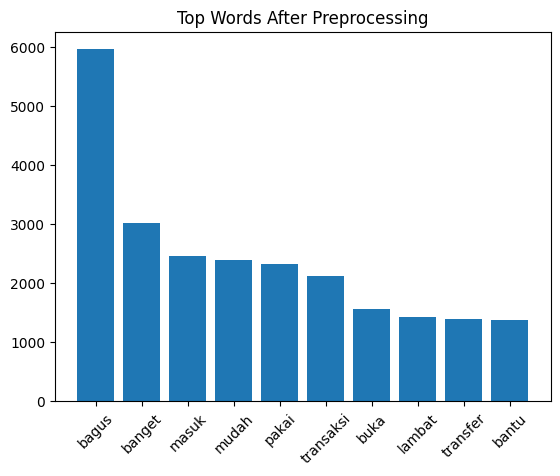

In [ ]:
import matplotlib.pyplot as plt

top_words = word_freq.most_common(10)
words, counts = zip(*top_words)

plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top Words After Preprocessing")
plt.show()

In [ ]:
df_bluRev.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24968 entries, 0 to 25786
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   content               24968 non-null  object
 1   score                 24968 non-null  int64 
 2   thumbsUpCount         24968 non-null  int64 
 3   reviewCreatedVersion  20861 non-null  object
 4   at                    24968 non-null  object
 5   replyContent          24968 non-null  object
 6   repliedAt             24968 non-null  object
 7   cleaned_content       24968 non-null  object
 8   tokens                24968 non-null  object
 9   filtered_tokens       24968 non-null  object
 10  token_count           24968 non-null  int64 
 11  tokens_stemmed        24968 non-null  object
 12  final_content         24968 non-null  object
 13  final_token_count     24968 non-null  int64 
 14  sentiment_label       24968 non-null  object
 15  tokens_filtered       24968 non-null  obj

In [ ]:
df_bluRev.head(10)

,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,cleaned_content,tokens,filtered_tokens,token_count,tokens_stemmed,final_content,final_token_count,sentiment_label,tokens_filtered
0,"udah lebih dr 1 mnggu, gk bisa di buka udah ga...",2,0,2.10.10,2026-03-30 09:10:30,"Hai, Kak Indah. Maaf atas ketidaknyamanannya. ...",2026-03-30 09:33:32,sudah lebih dari minggu tidak bisa di buka sud...,"[sudah, lebih, dari, minggu, tidak, bisa, di, ...","[minggu, buka, ganti, jaringan, dn, ganti, hp,...",21,"[minggu, buka, ganti, jaring, dn, ganti, hp, s...",minggu buka ganti jaring dn ganti hp sih data ...,11,negative,"[minggu, buka, ganti, jaring, dn, ganti, hp, s..."
1,"bener bener kecewa sama aplikasi ini, gw kira ...",1,0,NaN,2026-03-30 08:05:12,"Hai, Kak Esa. Maaf atas ketidaknyamanannya. BC...",2026-03-30 08:49:54,benar benar kecewa sama aplikasi ini saya kira...,"[benar, benar, kecewa, sama, aplikasi, ini, sa...","[kecewa, terpercaya, recomended, kantor, caban...",38,"[kecewa, percaya, recomended, kantor, cabang, ...",kecewa percaya recomended kantor cabang fisik ...,13,negative,"[kecewa, percaya, recomended, kantor, cabang, ..."
2,mantap,5,0,2.10.10,2026-03-30 08:01:13,"Hai, Kak Abdul. Terima kasih atas ulasannya. S...",2026-03-30 08:06:43,bagus,[bagus],[bagus],1,[bagus],bagus,1,positive,[bagus]
3,digital bank terbaik gaperlu ribet lagi pembay...,5,0,2.10.10,2026-03-30 07:38:52,"Hai, Kak Kenzin. Terima kasih atas ulasannya. ...",2026-03-30 08:06:06,digital bank terbaik gaperlu ribet lagi pembay...,"[digital, bank, terbaik, gaperlu, ribet, lagi,...","[terbaik, gaperlu, ribet, pembayaran, jenis, a...",9,"[baik, gaperlu, ribet, bayar, jenis, apa]",baik gaperlu ribet bayar jenis apa,6,positive,"[baik, gaperlu, ribet, bayar, jenis, apa]"
4,"aku tinggalkan blu, karena aplikasinya super l...",5,0,2.3.0,2026-03-30 07:00:00,"Hai, Kak Rizal. Maaf atas ketidaknyamanannya. ...",2026-03-30 08:02:48,saya tinggalkan blu karena aplikasinya super l...,"[saya, tinggalkan, blu, karena, aplikasinya, s...","[tinggalkan, aplikasinya, super, lambat]",7,"[tinggal, aplikasi, super, lambat]",tinggal aplikasi super lambat,4,positive,"[tinggal, aplikasi, super, lambat]"
5,alhamdulillah sangat bagus aplikasi nya terima...,5,0,2.10.10,2026-03-30 06:43:54,"Hai, Kak Syfa. Terima kasih atas ulasannya. Se...",2026-03-30 06:56:36,alhamdulillah sangat bagus aplikasi nya terima...,"[alhamdulillah, sangat, bagus, aplikasi, nya, ...","[alhamdulillah, bagus, terimakasih]",6,"[alhamdulillah, bagus, terimakasih]",alhamdulillah bagus terimakasih,3,positive,"[alhamdulillah, bagus, terimakasih]"
6,mantappp,5,0,2.10.10,2026-03-30 05:59:00,"Hai, Kak Bobi. Terima kasih atas ulasannya. Se...",2026-03-30 06:55:50,mantappp,[mantappp],[mantappp],1,[mantappp],mantappp,1,positive,[mantappp]
7,"Bagus banget, userfriendly, stabil, aman",5,0,2.10.10,2026-03-30 04:16:40,"Hai, Kakak. Terima kasih atas ulasannya. Semog...",2026-03-30 04:31:10,bagus banget userfriendly stabil aman,"[bagus, banget, userfriendly, stabil, aman]","[bagus, banget, userfriendly, stabil, aman]",5,"[bagus, banget, userfriendly, stabil, aman]",bagus banget userfriendly stabil aman,5,positive,"[bagus, banget, userfriendly, stabil, aman]"
8,good,5,0,2.10.10,2026-03-30 03:07:13,"Hai, Kak Eliata. Terima kasih atas ulasannya. ...",2026-03-30 04:31:01,good,[good],[good],1,[good],good,1,positive,[good]
9,enak egk ada administrasi bulanan,5,0,2.10.10,2026-03-29 23:07:53,"Hai, Kak Aini. Terima kasih atas ulasannya. Se...",2026-03-30 00:16:00,enak egk ada administrasi bulanan,"[enak, egk, ada, administrasi, bulanan]","[enak, egk, administrasi, bulanan]",5,"[enak, egk, administrasi, bulan]",enak administrasi bulan,4,positive,"[enak, administrasi, bulan]"


In [ ]:
selected_col = ['content', 'score', 'at', 'thumbsUpCount', 'replyContent',
                'sentiment_label', 'final_content', 'tokens_stemmed']

df_bluRev_preprocessed = df_bluRev[selected_col].copy()
df_bluRev_preprocessed.to_csv(r'df_bluRev_preprocessed.csv', index = False)